# ES98A: Assignment 5
Author: Jabir Hussain (2007942)

This assignment uses the following log-normal prior model for the permeability $\kappa$: $$\kappa(x; \mathbf{u}) = \exp(a(x;\mathbf{u}))$$ $$a(x; \mathbf{u}) = \mathbf{u}_0 + \sum_{k\in \mathbb{N}} \left(\mathbf{u}_{2k-1} \cos(kx) + \mathbf{u}_{2k} \sin(kx) \right)$$

with independent, normally distributed coefficients $\mathbf{u}_k \sim \mathcal{N}(0, (1+k)^{-4})$ for $k \in \mathbb{N} \cup \{0\}$. We write $\mu_{\mathbf{u}} = \bigotimes_{k \geq 0} \mathcal{N}(0, (1+k)^{-4})$ for the corresponding Gaussian prior distribution for $\mathbf{u}$ on the sequence space $\ell^2$, and we think of $\mu_{\mathbf{u}}$ as having the "formal prior PDF"

$$\rho_{\mathbf{u}}(u) \propto \exp \left( -\frac{1}{2}\sum_{k\in \mathbb{N} \cup \{0\}} (1+k)^4 u_k^2 \right)$$

Suppose we have some observations of this system and wish to update the model: we use MCMC to sample the posterior distribution of $\mathbf{u}$ and hence to make posterior predictions for trajectories and breakout times.

---

## Exercise 5.1.
Suppose that we make noisy observations of some local space averages of $a(\cdot ; \mathbf{u})$. Specifically, suppose that our observed data $\mathbf{y}$ takes the form $$\mathbf{y} = H\mathbf{u} + \mathbf{\epsilon}$$ $$H\mathbf{u} := \left( \frac{1}{10} \int_{0.4}^{0.5} a(x; \mathbf{u}) \text{dx}, \frac{1}{10} \int_{1.2}^{1.3} a(x; \mathbf{u} \text{dx}, \frac{1}{10} \int_{4.7}^{4.8} a(x; \mathbf{u}) \right)$$

In this exercise, we look to find the following:
*   An exact closed-form expression for the linear observation operator $H: \ell^2 \to \mathbb{R}^3$ via integrals of $a(\cdot; \mathbf{u})$.
*   A derivative of the negative log-likelihood $\Phi(\mathbf{u}; \mathbf{y})$ and the formal posterior density through combination of this likelihood with the Gaussian prior.

#### Finding the closed-form expression for $Hu$.
We can rewrite the integral intervals as $$(A_1, B_1) = (0.4, 0.5), \quad (A_2, B_2) = (1.2, 1.3), \quad (A_3, B_3) = (4.7, 4.8)$$

We can rewrite the integrals as $$(H\mathbf{u})_j := \frac{1}{10} \int_{A_j}^{B_j} a(x; \mathbf{u}) \text{dx}, \quad j \in \{1,2,3\}$$

Using the integrals of the trigonometric functions $$\int_A^B \cos(kx)\text{dx} = \frac{\sin(kB) - \sin(kA)}{k}, \quad \int_A^B \sin(kx) \text{dx} = \frac{\cos(kA) - \cos(kB)}{k},$$ we obtain the equations:

$$(H\mathbf{u})_1 = \frac{1}{10} \left[\mathbf{u}_0(0.5-0.4) + \sum_{k=1}^{\infty} \left( \mathbf{u}_{2k-1} \frac{\sin(0.5k) - \sin(0.4k)}{k} + \mathbf{u}_{2k}\frac{\cos(0.4k) - \cos(0.5k)}{k} \right) \right]$$

$$(H\mathbf{u})_2 = \frac{1}{10} \left[\mathbf{u}_0(1.3-1.2) + \sum_{k=1}^{\infty} \left( \mathbf{u}_{2k-1} \frac{\sin(1.3k) - \sin(1.2k)}{k} + \mathbf{u}_{2k}\frac{\cos(1.2k) - \cos(1.3k)}{k} \right) \right]$$

$$(H\mathbf{u})_3 = \frac{1}{10} \left[\mathbf{u}_0(4.8-4.7) + \sum_{k=1}^{\infty} \left( \mathbf{u}_{2k-1} \frac{\sin(4.8k) - \sin(4.7k)}{k} + \mathbf{u}_{2k}\frac{\cos(4.7k) - \cos(4.8k)}{k} \right) \right]$$

We now apply the midpoint notation. That is, for each interval, we define $$m_i := \frac{A_i +B_i}{2}, \quad \delta := \frac{B_i - A_i}{2}$$ where $m_1 = 0.45, m_2 = 1.25, m_3 = 4.75, \delta = 0.05$

Substituting the values $B_i-A_i=2\delta$ and the trigonometric identities $$\sin(kB_i)-\sin(kA_i)=2\cos(km_i)\sin(k\delta), \quad\cos(kA_i)-\cos(kB_i)=2\sin(km_i)\sin(k\delta),$$

we get

$$(H\mathbf{u})_i =\frac{1}{10}\left[ \mathbf{u}_0(2\delta) + \sum_{k=1}^{\infty}\frac{2\sin(k\delta)}{k} \Big( \mathbf{u}_{2k-1}\cos(km_i)+\mathbf{u}_{2k}\sin(km_i) \Big)\right],\qquad i\in\{1,2,3\} $$

$$\implies (Hu)_1
=\frac{1}{10}\left[
\mathbf{u}_0(0.1)
+\sum_{k=1}^{\infty}\frac{2\sin(0.05k)}{k}
\Big(
\mathbf{u}_{2k-1}\cos(0.45k)+\mathbf{u}_{2k}\sin(0.45k)
\Big)\right]$$
$$\implies (Hu)_2
=\frac{1}{10}\left[
\mathbf{u}_0(0.1)
+\sum_{k=1}^{\infty}\frac{2\sin(0.05k)}{k}
\Big(
\mathbf{u}_{2k-1}\cos(1.25k)+\mathbf{u}_{2k}\sin(1.25k)
\Big)\right]$$
$$\implies (Hu)_3
=\frac{1}{10}\left[
\mathbf{u}_0(0.1)
+\sum_{k=1}^{\infty}\frac{2\sin(0.05k)}{k}
\Big(
\mathbf{u}_{2k-1}\cos(4.75k)+\mathbf{u}_{2k}\sin(4.75k)
\Big)\right]$$

(Note: I recognise that expanding it is a little verbose, however it will be much easier to translate into code.)

#### Negative log-likelihood for the model

Suppose the error $\mathbf{\epsilon} = (\mathbf{\epsilon}_1, \mathbf{\epsilon}_2, \mathbf{\epsilon}_3)$ is independent of $\mathbf{u}$ with $\mathbf{\epsilon} \sim \mathcal{N}(0, \Gamma)$ where $\Gamma := \frac{1}{16}I_{3\times 3}$.

Therefore, conditioning on $u$, we have
$$
y|u \sim \mathcal{N}(H\mathbf{u}, \Gamma).
$$
The Gaussian log-likelihood (up to an additive constant independent of $u$) is $$ -\log \rho(y|u) = \frac{1}{2} (y-H\mathbf{u})^{\top}\Gamma^{-1}(y-H\mathbf{u}) + \text{const}. $$
Since $\Gamma^{-1}=16I$, this becomes
$$
\Phi(\mathbf{u}; \mathbf{y}):= \frac{1}{2} (y-H\mathbf{u})^{\top} \Gamma^{-1}(y-H\mathbf{u})
= \frac{1}{2}\cdot 16||y-H\mathbf{u}||_2^2 \\
= 8||y-H\mathbf{u}||_2^2 \\
= 8\sum_{j=1}^{3}\big||(H\mathbf{u})_j-y_j\big||^2.
$$


#### Finding the "formal posterior PDF"

We have
$$
y = H \mathbf{u} + \varepsilon,\qquad \varepsilon\sim \mathcal{N}(0,\Gamma),
$$
so conditional on $u$,
$$
y\mid u \sim \mathcal{N}(Hu,\Gamma).
$$

The multivariate Gaussian density of $y$ given $u$ is
$$
\rho(y\mid u)
= \frac{1}{(2\pi)^{m/2}|\Gamma|^{1/2}}
\exp \left(
-\frac12 (y-Hu)^\top \Gamma^{-1}(y-Hu)
\right),
$$
where $m=3$ because $y\in\mathbb{R}^3$.

Using the negative log of $\rho(y\mid u)$:
$$
-\log \rho(y\mid u) = \frac{1}{2} (y-Hu)^\top \Gamma^{-1}(y-Hu) + \frac{m}{2}\log(2\pi) +\frac{1}{2}\log|\Gamma|.
$$

The last two terms do **not** depend on $u$. Since in Bayesian inference and MH-MCMC we only need expressions up to proportionality in $u$, we package the $u$-dependent part as
$$
\Phi(u;y):=\frac{1}{2} (y-Hu)^\top \Gamma^{-1}(y-Hu).
$$

Then you can write succinctly:
$$
\rho(y\mid u)\propto \exp \big(-\Phi(u;y)\big),
$$

Given $\Gamma=\frac{1}{16}I$, we have $\Gamma^{-1}=16I$. Thus, we get
$$
\Phi(u;y)
=\frac12 (y-Hu)^\top (16I)(y-Hu)
=8,(y-Hu)^\top (y-Hu)
=8|y-Hu|_2^2.
$$
And in components (this is often the least ambiguous form):
$$
\Phi(u;y)=8\sum_{j=1}^3\big((Hu)_j-y_j\big)^2.
$$

Bayes’ rule is given by:
$$
\rho(\boldsymbol{u}\mid \boldsymbol{y})
=\frac{\rho(\boldsymbol{y}\mid \boldsymbol{u})\,\rho(\boldsymbol{u})}{\rho(\boldsymbol{y})}.
$$

* $\rho(u)$ is the prior density (as a function of $u$).
* $\rho(y\mid u)$ is the likelihood (as a function of $u$, for fixed observed $y$).
* $\rho(y)$ is the evidence, independent of $u$, defined by
  $$
  \rho(y)=\int \rho(y\mid u)\rho(u) du.
  $$

Since we only want to consider the posterior up to normalisation, we can write
$$
\rho(u\mid y)\propto \rho(y\mid u) \rho(u).
$$

Using the formal prior density
$$
\rho(u)\propto \exp \left(-\frac12\sum_{k\ge 0}(1+k)^4 u_k^2\right).
$$

and
$$
\rho(y\mid u)\propto \exp \big(-\Phi(u;y)\big),
$$

we can take their product, yielding
$$
\rho(u\mid y)
\propto
\exp\big(-\Phi(u;y)\big);
\exp\left(-\frac12\sum_{k\ge 0}(1+k)^4 u_k^2\right).
$$

Combine the exponentials $(\exp(A)\exp(B)=\exp(A+B))$:
$$
\rho(u\mid y)
\propto
\exp\left(
-\Phi(u;y)
-\frac12\sum_{k\ge 0}(1+k)^4 u_k^2
\right).
$$

Finally substitute $\Phi(u;y)=8|y-Hu|_2^2$:
$$
\rho(u\mid y)_{\mathbf{u} | \mathbf{y} = y}
\propto
\exp\left(
-8|y-Hu|_2^2
-\frac{1}{2}\sum_{k\in \mathbb{N} \cup \{0\}}(1+k)^4 u_k^2
\right).
$$

---

## Exercise 5.2. MH-MCMC sampling from posterior distribution

Suppose we observe $y=(4.8,5.1,4.3)$. Truncating all expansions for $u$ to $0 \leq k \leq K := 25$, we will use the MH-MCMC algorithm to draw approximate samples from the posterior distribution of $\mathbf{u}\mid\mathbf{y}=y.$ More specifically, we will use the preconditioned Crank-Nicolson (pCN) proposal. This methods acceptance and mixing properties are independent of state dimension $d$, depending only on the misfit potential $\Phi(u; y)$

We consider a target measure of the form $\mu (\mathrm{d} x) \propto \exp(- \Phi(x)) \mathcal{N} (0, C_{0}; \mathrm{d} x)$.

The preconditioned Crank-Nicolson proposal takes

$$y = \sqrt{1 - s^{2}} x + s \xi \text{ with } \xi \sim \mathcal{N} (0, C_{0})$$

with Metropolis acceptance using $\alpha(x, y) = \exp(\phi(x) - \phi(y))$.

We will tune the step size $s \in [0,1]$, then freeze $s$ to run the main chain.

In [63]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2007942)

K = 25
d = K + 1

# observed data
y_observed = np.array([4.8, 5.1, 4.3], dtype=float)

# observation windows (see Ex5.1. for details)
A_i = np.array([0.4, 1.2, 4.7], dtype=float)
B_i = np.array([0.5, 1.3, 4.8], dtype=float)
H_K = np.zeros((3, d), dtype=float)
H_K[:, 0] = (1.0 / 10.0) * (B_i - A_i)

# indices
j = np.arange(1, d)
# corresponding Fourier wavenumber
k = np.where(j % 2 == 1, (j + 1) // 2, j // 2).astype(float)

kA = np.outer(A_i, k)
kB = np.outer(B_i, k)


We use masking to populate the array in single vectorised steps rather than iterating across each value.

In [64]:
cos_mask = (j % 2 == 0)
sin_mask = ~cos_mask

H_K[:, j[cos_mask]] = (1.0 / 10.0) * (np.sin(kB[:, cos_mask]) - np.sin(kA[:, cos_mask])) / k[cos_mask]
H_K[:, j[sin_mask]] = (1.0 / 10.0) * (np.cos(kA[:, sin_mask]) - np.cos(kB[:, sin_mask])) / k[sin_mask]

# prior standard deviation
prior_std = (1.0 + np.arange(d, dtype=float))** (-2.0)

def prior_sample():
    return prior_std * np.random.normal(size=d)

def Phi(u):
    r = y_observed - H_K @ u
    return 8.0 * float(r @ r)

We use the functions defined in the Week 10 laboratory handout.
* `average_jump`: returns mean Euclidean step size
* `autocorr`: computes the lag autocorrelation of the chain by forming the normalised covariance
* `effective_sample_size_ratio`: quantifies how many effective independent samples the correlated chain has
* `adapt_step_size`: for every fixed interval, it estimates the average acceptance and increases/decreases the step size by a factor to keep acceptance within a given window.
* `pch_mh_mcmc` runs the pCN proposal generated with the prior standard deviation, calculating the negative log-likelihood at the proposal. This returns the full chain, acceptance statistics and final step size.

In [65]:
def average_jump(X):
    T = X.shape[0]
    return sum(np.linalg.norm(X[i, :] - X[i - 1, :]) for i in range(1, T)) / float(T)

def autocorr(seq, lag=0):
    assert len(seq.shape) == 1
    assert lag >= 0
    N = seq.shape[0]
    seq1 = seq[0:N - lag]
    seq2 = seq[lag:N]
    m1 = np.average(seq1)
    m2 = np.average(seq2)
    seq1c = seq1 - m1 * np.ones(seq1.shape)
    seq2c = seq2 - m2 * np.ones(seq2.shape)
    sigma11 = np.sum(seq1c * seq1c)
    sigma22 = np.sum(seq2c * seq2c)
    sigma12 = np.sum(seq1c * seq2c)
    if sigma11 == 0.0 or sigma22 == 0.0:
        return 1.0
    else:
        return sigma12 / np.sqrt(sigma11 * sigma22)

def effective_sample_size_ratio(seq, lags):
    return 1.0 / (1.0 + 2.0 * np.sum([autocorr(seq, l) for l in lags if l >= 1]))

def adapt_step_size(tuning, alpha_hist, step_size, step_size_min=0.0, step_size_max=np.inf):
    if len(alpha_hist) % tuning["interval"] != 0:
        return False, None, step_size
    if tuning["memory"] is None or tuning["memory"] is np.inf:
        a = np.average(alpha_hist)
    else:
        w = np.array([np.exp(-x / tuning["memory"]) for x in range(len(alpha_hist))], dtype=float)
        w /= np.sum(w)
        w = np.flip(w)
        a = float(np.dot(alpha_hist, w))
    if a > tuning["max"]:
        return True, a, min([step_size * tuning["factor"], step_size_max])
    if a < tuning["min"]:
        return True, a, max([step_size / tuning["factor"], step_size_min])
    return False, a, step_size

def pcn_mh_mcmc(potential, n_iter, x0, step_size, tune_for_alpha=None):
    X = [x0]
    alpha_hist = [0.0]
    pot_hist = [potential(x0)]
    n_accept = 0
    d_local = x0.shape[0]

    for n in range(n_iter):
        if tune_for_alpha is not None:
            adapted, a_value, step_size = adapt_step_size(
                tuning=tune_for_alpha,
                alpha_hist=alpha_hist,
                step_size=step_size,
                step_size_max=1.0,
            )

        # pCN restriction
        assert 0.0 <= step_size <= 1.0

        x = X[-1]
        pot_x = pot_hist[-1]

        # Propose using a prior draw xi ~ N(0, C0)
        xi = prior_std * np.random.normal(size=d_local)
        y = np.sqrt(1.0 - step_size**2.0) * x + step_size * xi
        pot_y = potential(y)

        # Accept/reject using log form
        log_alpha = min([0.0, pot_x - pot_y])
        log_u = np.log(np.random.random())
        alpha_hist.append(float(np.exp(log_alpha)))

        if log_u <= log_alpha:
            n_accept += 1
            X.append(y)
            pot_hist.append(pot_y)
        else:
            X.append(x)
            pot_hist.append(pot_x)

    # Return the final step_size so we can report the tuned value explicitly
    return np.array(X), n_accept, np.array(alpha_hist), step_size

We now run a tuning phase from a prior draw, adapting $s$ every 100 iterations using the acceptance windows defined in the lab.

In [66]:
tuning_policy = {
    "min": 0.20,
    "max": 0.50,
    "interval": 100,
    "factor": np.sqrt(2.0),
    "memory": 500,
    "verbose": False,
}
# Initial state from the prior
x0 = prior_sample()

# Random probe vector p (unit length)
p = np.random.normal(size=d)
p /= np.linalg.norm(p)

# Phase 1: tuning (burn-in)
n_tune = 5000
s0 = 0.5

X_tune, nA_tune, alpha_tune, s_tuned = pcn_mh_mcmc(
    potential=Phi,
    n_iter=n_tune,
    x0=x0,
    step_size=s0,
    tune_for_alpha=tuning_policy,
)


n_main = 30000
X_main, nA_main, alpha_main, s_fixed = pcn_mh_mcmc(
    potential=Phi,
    n_iter=n_main,
    x0=X_tune[-1],
    step_size=s_tuned,
    tune_for_alpha=None,
)

We then calculate a series of statistics to quantify the MH-MCMC performance.
* `accept_rate`: proportion of accepted proposed moves.
* `accept_prob`: average of the MH acceptance probabilities across the run.
* `avg_jump`: how far the chain moves per iteration.
* `Xp`: a one-dimensional summary of the chain used for autocorrelation.
* `ess_ratio_proj`: proportion of MCMC samples that are independent after considering autocorrelation.

In [67]:
# Performance statistics on the main chain
accept_rate = float(nA_main) / float(n_main)
accept_prob = float(np.average(alpha_main[1:]))  # skip the initial 0.0 entry
avg_jump = float(average_jump(X_main))

Xp = X_main @ p
lags = np.arange(0, 100, 1, dtype=int)
ess_ratio_proj = float(effective_sample_size_ratio(Xp, lags))
# ESS ratio for component 0
ess_ratio_u0 = float(effective_sample_size_ratio(X_main[:, 0], lags))

# Convert ESS ratio into an "effective number of samples" estimate
n_eff_proj = ess_ratio_proj * float(Xp.shape[0])

print(f"Tuned step size s = {s_fixed:.6f}")
print(f"Acceptance rate = {accept_rate:.6f}")
print(f"Average acceptance probability = {accept_prob:.6f}")
print(f"Average jump length = {avg_jump:.6f}")
print(f"ESS ratio for u·p = {ess_ratio_proj:.6f}  (effective samples ≈ {n_eff_proj:.1f})")
print(f"ESS ratio for u0 = {ess_ratio_u0:.6f}")


Tuned step size s = 0.707107
Acceptance rate = 0.395833
Average acceptance probability = 0.392303
Average jump length = 0.198448
ESS ratio for u·p = 0.029738  (effective samples ≈ 892.2)
ESS ratio for u0 = 0.029320


The tuned step size of $\approx \frac{1}{\sqrt{2}}$ resulted in an acceptance rate of 0.390 and an average acceptance probability of 0.38.

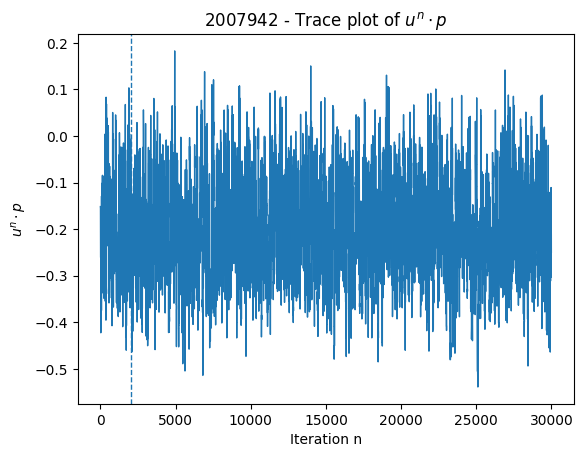

In [68]:
burnin_main = 2000  # burn-in within the main chain

n = np.arange(Xp.shape[0])

fig, ax = plt.subplots()
ax.plot(n, Xp, linewidth=1.0)
ax.axvline(burnin_main, linestyle="--", linewidth=1.0)

ax.set_title("2007942 - Trace plot of $u^n\\cdot p$")
ax.set_xlabel("Iteration n")
ax.set_ylabel("$u^n\\cdot p$")
plt.show()

The trace plot shows no clear trend nor does it show flat regions, showing the chain is mixing well. The ESS ratio of 0.0297 means ~3% of samples are effective in the direction of $u\cdot p$, which matches the trace plot.


---

## Exercise 5.3

The aim is to visualise and compare the joint marginal distributions of $(u_0,u_1,u_2)$ under the posterior (using post–burn-in MH–MCMC samples) and under the prior (using i.i.d. samples). The required output is a triangular grid of plots: histograms on the diagonal and scatter plots on the lower triangle.

In what follows, the posterior sample set is taken from the production chain `X_main`. A burn-in cutoff is applied, then the remaining chain is optionally thinned and capped for plotting clarity. A matched number of i.i.d. prior samples is then generated for a fair side-by-side comparison.

In [69]:
# Burn-in within the production chain and plotting controls
thin = 5                # thinning only for visual clarity
max_points = 6000       # cap number of plotted points for readability

# Extract posterior samples for (u0,u1,u2)
U_post_full = X_main[burnin_main:, :3]
U_post_thin = U_post_full[::thin, :]

if U_post_thin.shape[0] > max_points:
    U_post = U_post_thin[:max_points, :]
else:
    U_post = U_post_thin

N_plot = U_post.shape[0]
N_plot

5601

The number `N_plot` is the number of posterior draws used in the plots. The same number of i.i.d. prior draws will be generated so that the posterior and prior visualisations have comparable sample sizes.

In [70]:
# Generate N_plot i.i.d. prior draws and retain only (u0,u1,u2)
U_prior = np.array([prior_sample()[:3] for _ in range(N_plot)], dtype=float)

To ensure the posterior and prior plots are directly comparable, the axis limits are chosen from the pooled range of both datasets, with a small padding. The same histogram bin edges are also used for both figures.

In [71]:
U_all = np.vstack([U_post, U_prior])
mins = U_all.min(axis=0)
maxs = U_all.max(axis=0)

pad = 0.05 * (maxs - mins + 1e-12)
lims = np.column_stack([mins - pad, maxs + pad])  # shape (3,2)

The following helper creates the requested triangular grid: histograms of $u_0,u_1,u_2$ on the diagonal and scatter plots for $(u_0,u_1)$, $(u_0,u_2)$, $(u_1,u_2)$ in the lower triangle. The upper triangle is left blank, matching the exercise specification.

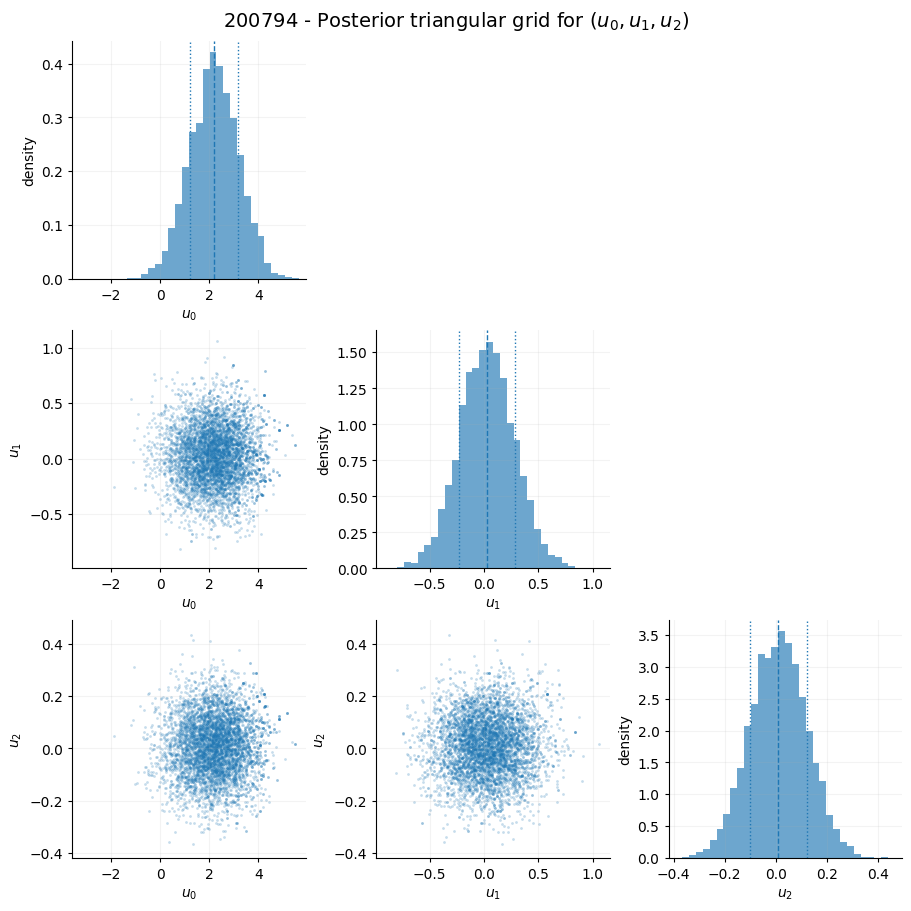

In [72]:
def triangular_grid(U, lims, bins, title):
    labels = [r"$u_0$", r"$u_1$", r"$u_2$"]

    fig, axes = plt.subplots(3, 3, figsize=(9, 9), constrained_layout=True)
    fig.suptitle(title, fontsize=14)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.15, linewidth=0.8)
        ax.tick_params(direction="out", length=3, width=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Diagonal histograms + mean/std markers
    for i in range(3):
        ax = axes[i, i]
        data = U[:, i]

        ax.hist(data, bins=bins[i], density=True, alpha=0.65)
        ax.set_xlim(lims[i, 0], lims[i, 1])
        ax.set_xlabel(labels[i])
        ax.set_ylabel("density")

        m = float(np.mean(data))
        s = float(np.std(data, ddof=1))
        ax.axvline(m, linestyle="--", linewidth=1.0)
        ax.axvline(m - s, linestyle=":", linewidth=1.0)
        ax.axvline(m + s, linestyle=":", linewidth=1.0)

    pairs = [(1, 0), (2, 0), (2, 1)]
    for (r, c) in pairs:
        ax = axes[r, c]
        ax.scatter(
            U[:, c], U[:, r],
            s=4, alpha=0.25,
            linewidths=0,
            rasterized=True
        )
        ax.set_xlim(lims[c, 0], lims[c, 1])
        ax.set_ylim(lims[r, 0], lims[r, 1])
        ax.set_xlabel(labels[c])
        ax.set_ylabel(labels[r])

    for r in range(3):
        for c in range(3):
            if c > r:
                axes[r, c].axis("off")

    return fig, axes


bins = [np.linspace(lims[i, 0], lims[i, 1], 35) for i in range(3)]

# posterior plot
fig_post, _ = triangular_grid(
    U_post, lims, bins,
    title="200794 - Posterior triangular grid for $(u_0,u_1,u_2)$"
)
plt.show()

The plots give insight into the following:
* The histogram for $u_0$ is consistently positive, which is expected for positive average of $a(x; u)$ as the constant mode is the dominant term
* $u_1, u_2$ are centred near zero with somewhat symmetric shape, similar to a Gaussian.
* The shape of the scatter plots show that the posterior correlation is small
* The data are local averages, and the constant term $u_0$ shifts $a(x;u)$ everywhere in the same direction, so the easiest way for the posterior to match the observed values is to adjust $u_0$ rather than the oscillatory terms $u_1, u_2$.

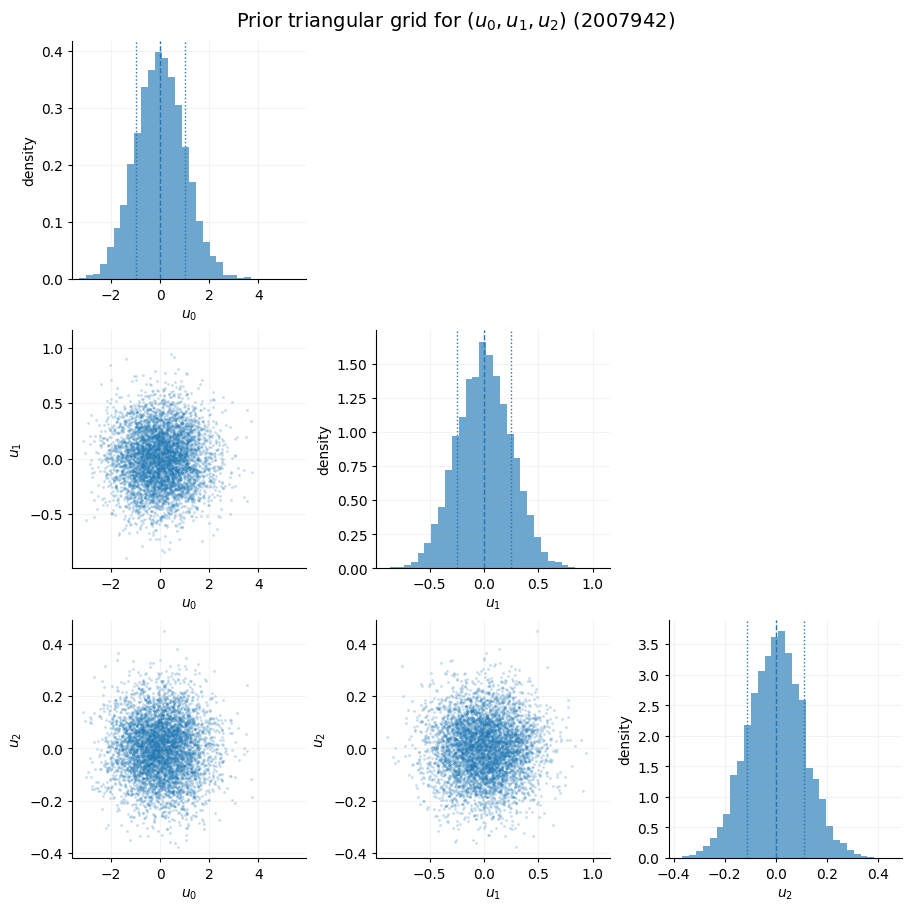

In [73]:
# vanilla MC triangular grid
fig_prior, _ = triangular_grid(
    U_prior, lims, bins,
    title="Prior triangular grid for $(u_0,u_1,u_2)$ (2007942)"
)
plt.show()


For the prior (Vanilla MC), the marginals are centred around 0 with unstructured clouds for the scatter plots. This is consistent with independent Gaussian coefficients that have a mean of 0 and decreasing variance (as variance is given by $\text{Var}(u_k) = (1+k)^{-4})$; this also means that $u_0$ is broader than $u_1, u_2$ as highlighted by their x-axes on the density plots.

---

## Exercise 5.4.

In this exercise, we will use five "reasonably independent" posterior samples $\mathbf{u}^n$ and plot the corresponding log-permeability $a(x; \mathbf{u^n})$ and permeability $\kappa(x; u^n) = \exp(a(x; u^n))$ on $x\in [0,6]$. We simulate the ODE $$\dot{x} = \kappa(x(t); u), \quad x(0) = 1$$ until $t = \max(0.2, t_*(\mathbf{u}^n))$ where $t_*(u) = \min{t \geq 0: x(t; u) \geq 6}$.

The posterior sample is considered "reasonably independent" if the corresponding MCMC states are separated by several coorelation lengths. We derive this from the effective sample size (ESS) from Exercise 5.2. More specifically, if the ESS ratio for $u^n\cdot p$ is $r$ then the successive states are independent only after a lag vy order $\frac{1}{r}$.

In [74]:
# Post–burn-in selection of five "reasonably independent" posterior samples using ESS-informed spacing
t_min = 0.2
x_star = 6.0

ess_ratio = float(ess_ratio_proj)  # computed in Exercise 5.2 for the projection u·p

# Conservative spacing: a few correlation lengths
stride = int(np.ceil(5.0 / ess_ratio))
stride = max(stride, 1)

N_chain = X_main.shape[0]
max_start = max(0, (N_chain - 1) - 4 * stride)
start = min(burnin_main, max_start)

idx_post = start + stride * np.arange(5, dtype=int)

U_post5 = X_main[idx_post, :]
U_prior5 = np.array([prior_sample() for _ in range(5)], dtype=float)

`idx_post` stores the selected posterior iterations, where the stride is mathematically grounded with the ESS ratio. We now evaluate $a(x;u)$ on grid $x\in [0,6$ for each of the prior draws and posterior samples.

In [75]:
def a_of_x(x, u):
    x = np.asarray(x, dtype=float)

    result = float(u[0]) * np.ones_like(x)

    u_cos = u[1::2]  # u1, u3, u5, ...
    u_sin = u[2::2]  # u2, u4, u6, ...

    if u_cos.size > 0:
        k_cos = np.arange(1, u_cos.size + 1, dtype=float)
        result = result + np.cos(np.outer(x, k_cos)) @ u_cos

    if u_sin.size > 0:
        k_sin = np.arange(1, u_sin.size + 1, dtype=float)
        result = result + np.sin(np.outer(x, k_sin)) @ u_sin

    return result

def kappa_of_x(x, u):
    return np.exp(a_of_x(x, u))

Using these functions, we can plot both $a(x;u)$ and $\kappa(x;u)$, comparing the five posterior samples with five i.i.d prior draws.

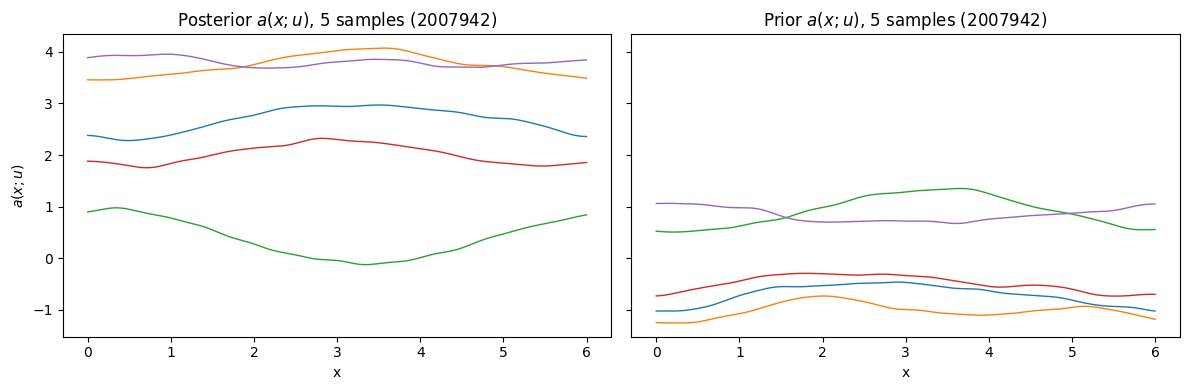

In [76]:
x_grid = np.linspace(0.0, 6.0, 1001)

A_post = np.array([a_of_x(x_grid, u) for u in U_post5])
A_prior = np.array([a_of_x(x_grid, u) for u in U_prior5])

K_post = np.exp(A_post)
K_prior = np.exp(A_prior)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for i in range(5):
    ax[0].plot(x_grid, A_post[i], linewidth=1.0)
    ax[1].plot(x_grid, A_prior[i], linewidth=1.0)

ax[0].set_title("Posterior $a(x;u)$, 5 samples (2007942)")
ax[1].set_title("Prior $a(x;u)$, 5 samples (2007942)")
ax[0].set_xlabel("x"); ax[1].set_xlabel("x")
ax[0].set_ylabel("$a(x;u)$")

plt.tight_layout()
plt.show()


In the posterior plot, $a(x;u)$ is primarily between zero and four as opposed the prior plot, which shows more curves below zero. Observations are local averages of $a$, so conditioning on $y$ pushes the level of $a$ upwards (mainly through the constant term $u_0$). They both show smooth variation in the range of values $x$ can take; since the variance decay is calculated via $(1+k)^{-4}$, high frequency Fourier modes are damped significantly, yielding smoth curves.

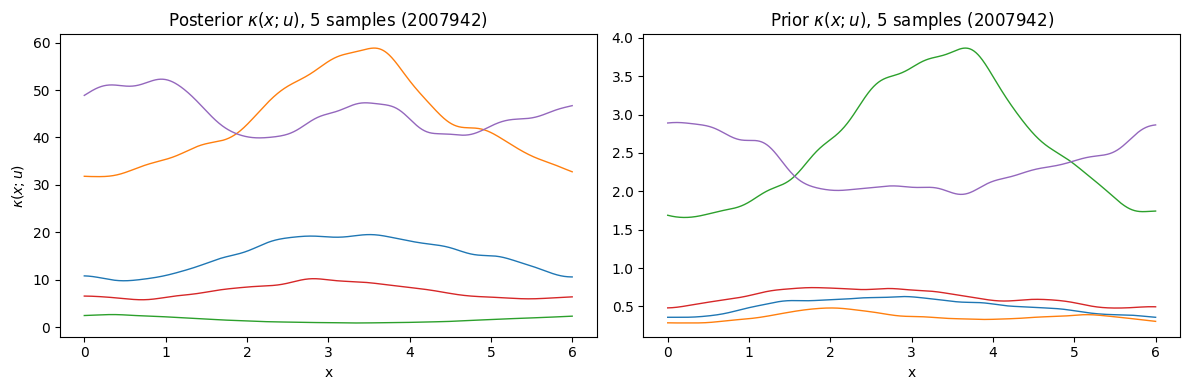

In [77]:
# kappa curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for i in range(5):
    ax[0].plot(x_grid, K_post[i], linewidth=1.0)
    ax[1].plot(x_grid, K_prior[i], linewidth=1.0)

ax[0].set_title("Posterior $\\kappa(x;u)$, 5 samples (2007942)")
ax[1].set_title("Prior $\\kappa(x;u)$, 5 samples (2007942)")
ax[0].set_xlabel("x"); ax[1].set_xlabel("x")
ax[0].set_ylabel("$\\kappa(x;u)$")

plt.tight_layout()
plt.show()


Conversely, there is a significant difference in magnitude between the posterior and prior $\kappa(x;u)$ The prior curves are below four, whereas the posterior curves range in value from 10-60. Since $\kappa = \exp(a)$, there is a multiplicative jump in value. This exponentiation means small pertubations in $a$ lead to significant changes in value as opposed to the $a(x;u)$ plots.

When $\kappa$ is lower, motion slows and in turn this means high $\kappa$ translates to faster motion in that region. This means the changes in the curve translate to the steepness in the trajectory $x(t)$.

In [78]:
def simulate_trajectory(u, dx=1e-3, t_min=0.2, x0=1.0, x_star=6.0):
    x_path = np.arange(x0, x_star + dx, dx)
    k_left = kappa_of_x(x_path[:-1], u)
    dt = dx / k_left

    t_path = np.concatenate([[0.0], np.cumsum(dt)])
    t_star = float(t_path[-1])

    if t_star < t_min:
        t_extra = np.linspace(t_star, t_min, 200)
        x_extra = x_star * np.ones_like(t_extra)
        t_path = np.concatenate([t_path, t_extra[1:]])
        x_path = np.concatenate([x_path, x_extra[1:]])

    return t_path, x_path, t_star


We now plot the posterior and prior trajectories.

Posterior breakout times t_*: [0.32211298 0.11364472 3.93313023 0.65452022 0.11442667]
Prior breakout times t_*    : [ 9.77130954 13.28336353  1.91324551  8.05374139  2.24903161]


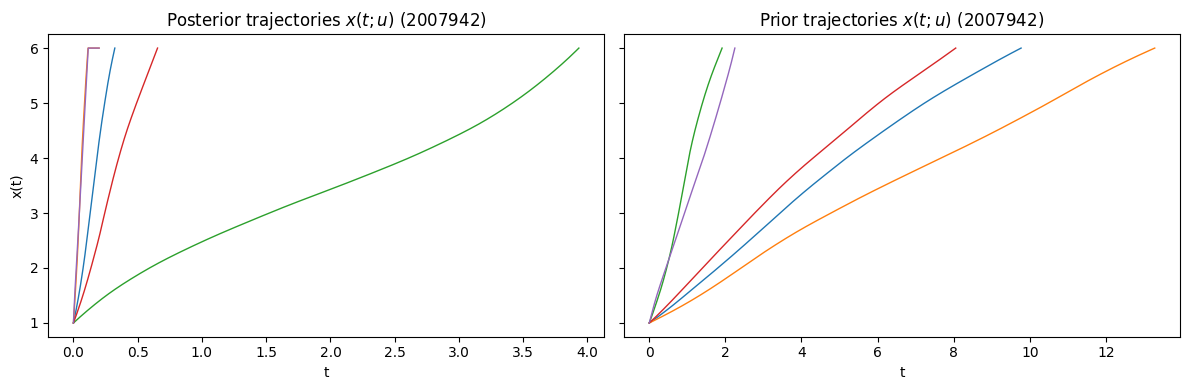

In [79]:
traj_post = [simulate_trajectory(u, dx=1e-3, t_min=t_min, x0=1.0, x_star=x_star) for u in U_post5]
traj_prior = [simulate_trajectory(u, dx=1e-3, t_min=t_min, x0=1.0, x_star=x_star) for u in U_prior5]

tstar_post = np.array([tr[2] for tr in traj_post], dtype=float)
tstar_prior = np.array([tr[2] for tr in traj_prior], dtype=float)

print("Posterior breakout times t_*:", tstar_post)
print("Prior breakout times t_*    :", tstar_prior)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for (t_path, x_path, t_star) in traj_post:
    ax[0].plot(t_path, x_path, linewidth=1.0)

for (t_path, x_path, t_star) in traj_prior:
    ax[1].plot(t_path, x_path, linewidth=1.0)

ax[0].set_title("Posterior trajectories $x(t;u)$ (2007942)")
ax[1].set_title("Prior trajectories $x(t;u)$ (2007942)")
ax[0].set_xlabel("t"); ax[1].set_xlabel("t")
ax[0].set_ylabel("x(t)")

plt.tight_layout()
plt.show()


The posterior trajectory reach $x=6$ considerably faster than the prior trajectorys, with all but one of the posterior trajectories reaching it before $t=1$; this matches the statements made about how the permeability plots represent motion. The slope of each curve represents the permeability evaluated along that trajectory. The colours of each curve correspond with those same colours in the $\kappa$ plots, visually highlighting how low $\kappa$ results in a longer time to reach $x=6.$

---

## Exercise 5.5.

This exercise uses all N terms in the MCMC simulation to estimate the following
quantities of interest:
* the sample average and sample covariance matrix of $\mathbf{u}|\mathbf{y}= y$
* for $x(t; \mathbf{u}|\mathbf{y}= y)$ at $t=1/10$, we will estimate the mean and standard deviation and produce a histogram;
* for $t_*(\mathbf{u}|\mathbf{y}= y)$, we estimate the mean and standard deviation and produce a histogram.



In [80]:
U_post = X_main[burnin_main:, :]
N_post, d = U_post.shape

The prior mean is zero, and the prior standard deviation is given by the formula $\text{std}(u_k) = (1+k)^{-2}$. We estimate the posterior mean and covariance of $\mathbf{u} \mid \mathbf{y}$.

In [81]:
# Posterior mean and covariance of u|y
u_mean_posterior = np.mean(U_post, axis=0)
Cov_posterior = np.cov(U_post, rowvar=False, ddof=1)

# Prior mean/std (theoretical)
u_mean_prior = np.zeros(d)
u_std_prior = prior_std  # already defined earlier: (1+k)^(-2)

# Posterior std from covariance diagonal
u_std_post = np.sqrt(np.diag(Cov_posterior))

# Print a compact summary for the first few components
m = 8
print("Component k :  posterior mean   posterior std    prior mean   prior std")
for k in range(m):
    print(f"{k:10d} : {u_mean_posterior[k]:14.6f} {u_std_post[k]:14.6f} {u_mean_prior[k]:11.6f} {u_std_prior[k]:10.6f}")

Component k :  posterior mean   posterior std    prior mean   prior std
         0 :       2.193935       0.991286    0.000000   1.000000
         1 :       0.026935       0.256406    0.000000   0.250000
         2 :       0.009630       0.111691    0.000000   0.111111
         3 :       0.003273       0.062061    0.000000   0.062500
         4 :      -0.001449       0.040334    0.000000   0.040000
         5 :      -0.000044       0.027672    0.000000   0.027778
         6 :      -0.000517       0.020558    0.000000   0.020408
         7 :      -0.000914       0.015788    0.000000   0.015625


We estimate $x(\frac{1}{10}; u)$ and $t_*(u)$ under both the posterior and prior. We can calculate time as a function of space in the form $$dt \approx \frac{dx}{\kappa(x; u)}$$ along $x=1$ to $x=6$. From this, we can estimate $t_*(u)$ as the accumulated time to reach $x=6$, and an estimate of $a(x; u)$ by means of linear interpolation.

In [82]:
t = 0.1
x0 = 1.0
x_star = 6.0
dx = 0.01
batch_size = 2000

x_left = np.arange(x0, x_star, dx) # does not include x_star
x_right = x_left + dx

# Precompute Fourier bases on x_left for the truncation implied by u (length d)
u_cos_len = U_post[0, 1::2].shape[0]
u_sin_len = U_post[0, 2::2].shape[0]

k_cos = np.arange(1, u_cos_len + 1, dtype=float)
k_sin = np.arange(1, u_sin_len + 1, dtype=float)

Cos_basis = np.cos(np.outer(x_left, k_cos))
Sin_basis = np.sin(np.outer(x_left, k_sin))

We then creater a function that computes time as a function of space: $$\frac{dt}{dx} = \frac{1}{\kappa(x;u)} \implies t_*(u) = \int_{x_0}^{x_*} \frac{1}{\kappa(x;u)}dx$$ and then approximate it by a Riemann sum on a grid with spacing `dx.`

In [83]:
def xt_and_tstar_from_samples(U):
    n = U.shape[0]
    x_at_t = np.empty(n, dtype=float)
    t_star = np.empty(n, dtype=float)

    # batch processing as doing it all in one contiguous block of
    # vectorised code is not computationally effective, not on my
    # personal machine at least
    for s in range(0, n, batch_size):
        e = min(s + batch_size, n)
        Ub = U[s:e, :]
        # constant mode, cosine coefficients, sine coeffs.
        u0b = Ub[:, 0]
        ucosb = Ub[:, 1::2]
        usinb = Ub[:, 2::2]

        # cosine and sine terms are evaluated in one matrix mult. each
        Ab = u0b[:, None] + (ucosb @ Cos_basis.T)
        if usinb.size > 0:
            Ab = Ab + (usinb @ Sin_basis.T)
        # exponentiate log-permeability to get kappa
        Kb = np.exp(Ab)
        # discretised dt = dx/kappa
        dtb = dx / Kb
        # cumulative time
        tb = np.cumsum(dtb, axis=1)

        t_star_b = tb[:, -1]
        t_star[s:e] = t_star_b

        # fast is if the breakout happens pre time=t
        fast = t_star_b < t
        x_at_t_b = np.empty(e - s, dtype=float)
        x_at_t_b[fast] = x_star

        # we invert the cumulative-time array to find the spatial point that
        # identifies time t
        if np.any(~fast):
            tb_slow = tb[~fast, :]
            # first index where t >= t
            crossed = tb_slow >= t
            j = crossed.argmax(axis=1)

            t_prev = np.where(j == 0, 0.0, tb_slow[np.arange(j.size), j - 1])
            x_prev = np.where(j == 0, x0, x_right[j - 1])

            t_next = tb_slow[np.arange(j.size), j]
            # linear interpolation within the step of width dx
            frac = (t - t_prev) / (t_next - t_prev + 1e-15)
            x_at_t_b[~fast] = x_prev + frac * dx

        x_at_t[s:e] = x_at_t_b

    return x_at_t, t_star

We compute the posterior estimates for $x(1/10; u), t_*(u)$ using the MCMC states. We generate $N$ i.i.d draws from $\mathcal{N}(0,C_0)$ with the same sample size as the posterior.

In [84]:
x01_post, tstar_post = xt_and_tstar_from_samples(U_post)

# Prior predictions using i.i.d. Monte Carlo draws (same N_post)
U_prior = prior_std[None, :] * np.random.normal(size=(N_post, d))
x01_prior, tstar_prior = xt_and_tstar_from_samples(U_prior)

# Summary statistics
def mean_std(z):
    return float(np.mean(z)), float(np.std(z, ddof=1))

x01_post_mean, x01_post_std = mean_std(x01_post)
x01_prior_mean, x01_prior_std = mean_std(x01_prior)

tstar_post_mean, tstar_post_std = mean_std(tstar_post)
tstar_prior_mean, tstar_prior_std = mean_std(tstar_prior)

print("x(0.1;u) posterior: mean =", x01_post_mean, "std =", x01_post_std)
print("x(0.1;u) prior    : mean =", x01_prior_mean, "std =", x01_prior_std)
print()
print("t* posterior: mean =", tstar_post_mean, "std =", tstar_post_std)
print("t* prior    : mean =", tstar_prior_mean, "std =", tstar_prior_std)


x(0.1;u) posterior: mean = 2.341228669471866 std = 1.2410367978525387
x(0.1;u) prior    : mean = 1.1646360633548511 std = 0.2116277764681929

t* posterior: mean = 0.9444237202097203 std = 1.23573916997991
t* prior    : mean = 8.4062375206769 std = 11.269539717262159


We plot these distributions using histograms. These plots compare the posterior and prior distributions of $x(0.1; u)$, with the second comparing the posterior and prior distributions for $t_*(u)$.

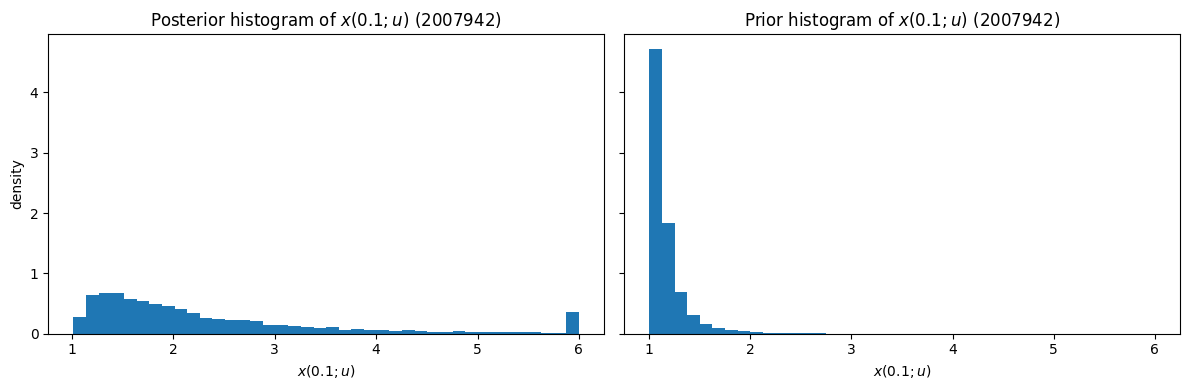

In [85]:
# Histogram for x(0.1;u): posterior vs prior
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax[0].hist(x01_post, bins=40, density=True)
ax[1].hist(x01_prior, bins=40, density=True)

ax[0].set_title("Posterior histogram of $x(0.1;u)$ (2007942)")
ax[1].set_title("Prior histogram of $x(0.1;u)$ (2007942)")
for j in range(2):
    ax[j].set_xlabel("$x(0.1;u)$")
ax[0].set_ylabel("density")

plt.tight_layout()
plt.show()


The prior histogram is concentrated near 1 whereas the posterior histogram is spread between 1 and 6. As $\kappa$ grows, so does $x(t;u)$ at fixed time $t$. The posterior distribution has broader uncertainty since exponentiating introduces multiplicative uncertainty: a moderate spread in $a$ translates to a variety of values for $\dot{x}$. The posterior plot has a significant bar near $x(0.1; u) = 6$; this means a fraction of the posterior samples predict reaching $x=6$ by the time $t = \frac{1}{10}$, which isn't shared with the prior histogram. These plots show that conditioning on $y$ increases the predicted transport speed.

The posterior and prior histograms below compare the distribution of the breakout time.

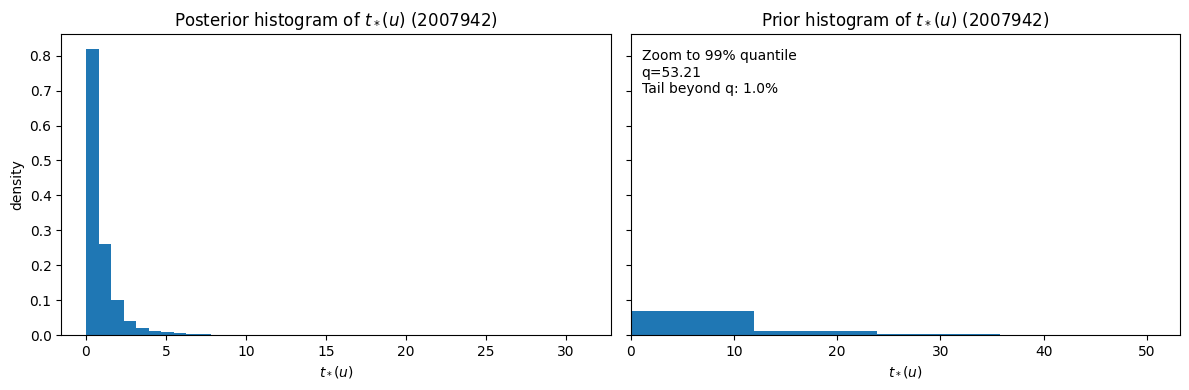

In [86]:
q = np.quantile(tstar_prior, 0.99)
tail_frac = float(np.mean(tstar_prior > q))

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax[0].hist(tstar_post, bins=40, density=True)
ax[1].hist(tstar_prior, bins=40, density=True)

ax[0].set_title("Posterior histogram of $t_*(u)$ (2007942)")
ax[1].set_title("Prior histogram of $t_*(u)$ (2007942)")

ax[0].set_xlabel("$t_*(u)$")
ax[1].set_xlabel("$t_*(u)$")
ax[0].set_ylabel("density")

ax[1].set_xlim(0.0, q)
ax[1].text(
    0.02, 0.95,
    f"Zoom to 99% quantile\nq={q:.2f}\nTail beyond q: {100*tail_frac:.1f}%",
    transform=ax[1].transAxes,
    va="top"
)

plt.tight_layout()
plt.show()


Note: the x-axis for the prior goes up to the 99th percentile, as when plotting the full histogram, there are values that go up to 400. This makes it difficult to interpret the data in a graphical setting, so the quantile approach is a compromise I have taken.

The posterior breakout times are significantly smaller than those in the prior histogram. Under the posterior, it reaches $x=6$ in less time. Recall that $$t_*(u) = \int_{x_0}^6 \frac{1}{\kappa(x; u)}.$$ For larger $\kappa$, the integral is smaller and thus so is $t_*$. Conversely, we can use this interpretation to justify why the prior has such a heavy right tail. For small $\kappa$, motion is considerably slower.